In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [9]:
# Tạo dữ liệu giả định
house_are = np.array([50, 70, 80, 100, 120]) # Diện tích của ngôi nhà (m2)
house_price = np.array([200, 270, 300, 370, 450]) # Giá của ngôi nhà (nghìn USD)

# Tạo dataframe
data = pd.DataFrame({
    'house_are': house_are,
    'house_price': house_price
})

data

,house_are,house_price
0,50,200
1,70,270
2,80,300
3,100,370
4,120,450


In [10]:
# Thực hiện hồi quy tuyến tính
# Chú ý: sklearn yêu cầu reshape dữ liệu đầu vào
X = house_are.reshape(-1,1)
y = house_price

X

array([[ 50],
       [ 70],
       [ 80],
       [100],
       [120]])

In [11]:
# Tạo và huấn luyện mô hình
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
print("Điểm cắt (intercept): " , model.intercept_)
print("Hệ số góc (slope): ", model.coef_[0])
print("R-squared:", model.score(X, y))

Điểm cắt (intercept):  20.547945205479493
Hệ số góc (slope):  3.541095890410958
R-squared: 0.9982260498050523


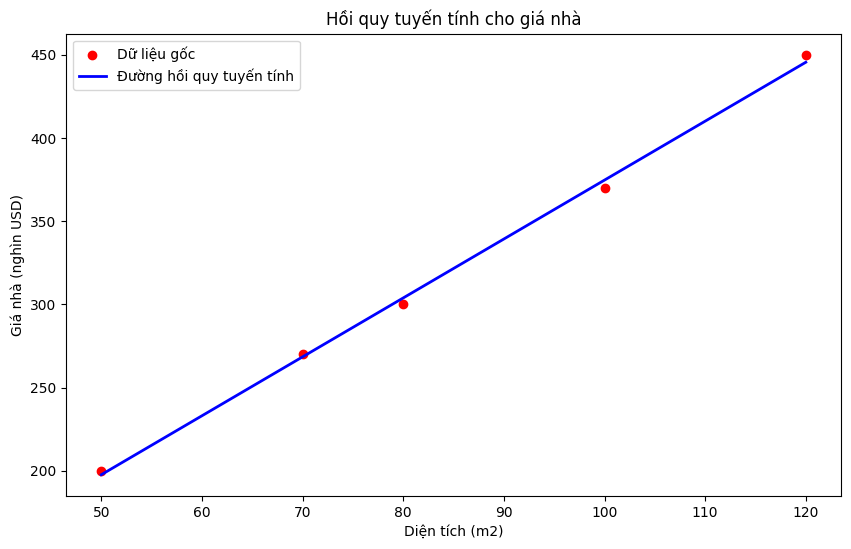

In [13]:
# Vẽ biểu đồ
plt.figure(figsize=(10,6))
plt.scatter(house_are, house_price, color='red', label='Dữ liệu gốc')
plt.plot(house_are, model.predict(X), color='blue', linewidth=2, label='Đường hồi quy tuyến tính')
plt.xlabel('Diện tích (m2)')
plt.ylabel('Giá nhà (nghìn USD)')
plt.title('Hồi quy tuyến tính cho giá nhà')
plt.legend()
plt.show()

In [14]:
# Sử dụng mô hình để dự đoán
new_house_area = np.array([85, 110, 150]).reshape(-1,1)
predicted_prices = model.predict(new_house_area)

print("\nDự đoán giá nhà cho diện tích 85m2, 110m2 và 150m2:")
for area, price in zip(new_house_area.flatten(), predicted_prices):
   print(f"Diện tích {area} m²: {price:.2f} nghìn USD")


Dự đoán giá nhà cho diện tích 85m2, 110m2 và 150m2:
Diện tích 85 m²: 321.54 nghìn USD
Diện tích 110 m²: 410.07 nghìn USD
Diện tích 150 m²: 551.71 nghìn USD
